# Sequence Length Sensitivity in LSTMs
### Scaler DL-I Final Project - Section 2 / Task 2 (Topic 21)

**Question.** *Train an LSTM on sequences of length 10, 50, and 200. Measure
accuracy and training time. Show how performance changes with sequence length.*

**Why this is interesting (and not just "longer = slower").** A vanilla
recurrent network must carry information from where it appears to where it is
read out, one timestep at a time. The longer that path, the more the gradient
signal is attenuated (vanishing-gradient problem) and the harder it is to
preserve the relevant bit. LSTMs were designed precisely to lengthen this
*memory horizon* via gated cell state. So this experiment is really probing:
**how far back can an LSTM reliably remember, at a fixed training budget - and
is the limiting factor the sequence *length* or the *distance* the information
has to travel?**

**Controlled task - *delayed-signal recall*.** We construct a synthetic binary
classification task we fully control:
- Each input is a length-`L` sequence with **two channels**.
- Channel 0 is pure `N(0, 1)` noise at every timestep (a distractor).
- Channel 1 is **zero everywhere except at one known position**, where it holds
  a clean marker: `+1` for class 1, `-1` for class 0.
- The model reads the whole sequence and classifies from the **final timestep**.

Because the marker is clean and unambiguous *when it appears*, the only
difficulty is **memory over distance** - exactly the variable we want to study.
There is nothing to "detect"; there is only something to *remember*.

**Four controlled experiments (deliberately exceeding the 3-length ask):**
1. **Length sweep** `[10, 20, 30, 50, 100, 200]` × 5 seeds - accuracy and
   training time vs length (signal at the *start*, so distance = L−1).
2. **Distance control** at fixed `L = 200` - signal at *start* vs *end*. This
   isolates distance from length and is the headline insight.
3. **LSTM vs vanilla RNN** across the same length sweep - does gating actually
   buy a longer horizon?
4. **Forget-gate bias** - re-run the LSTM with the forget bias initialised to
   `+2` to test whether the measured "horizon" is a capacity limit or just an
   initialization artifact.

Everything uses a single `CONFIG` dict, a `set_seed` helper, multi-seed runs for
error bars, pandas result tables, and labelled matplotlib/seaborn figures.

## 1. Setup

In [ ]:
# !pip -q install torch numpy pandas matplotlib seaborn

import time, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch", torch.__version__, "| device:", DEVICE)

torch 2.12.0+cpu | device: cpu


In [2]:
CONFIG = {
    "n_train":   2000,   # synthetic samples per training set
    "n_test":    500,
    "hidden":    64,     # hidden units
    "layers":    1,      # single recurrent layer (keeps the horizon effect clean)
    "lr":        1e-3,
    "grad_clip": 1.0,    # gradient-norm clipping - stabilises training; without it
                         #   even short lengths can collapse to chance on bad seeds
    "epochs":    30,     # FIXED budget for every run -> fair length comparison
    "batch_size":64,
    "lengths":   [10, 20, 30, 50, 100, 200],  # incl. the required 10/50/200
    "seeds":     [0, 1, 2, 3, 4],             # 5 seeds -> mean +/- std
}
CONFIG

{'n_train': 2000,
 'n_test': 500,
 'hidden': 64,
 'layers': 1,
 'lr': 0.001,
 'grad_clip': 1.0,
 'epochs': 30,
 'batch_size': 64,
 'lengths': [10, 20, 30, 50, 100, 200],
 'seeds': [0, 1, 2, 3, 4]}

In [3]:
def set_seed(seed: int):
    # Seed python / numpy / torch for reproducible model init & shuffling.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

## 2. The delayed-signal recall task

`make_dataset` builds `(X, y)` where `X` has shape `(N, L, 2)`:
- `X[:, :, 0]` - i.i.d. `N(0, 1)` noise (distractor channel).
- `X[:, :, 1]` - all zeros except at `signal_pos`, where it is `+1`/`-1`.

`signal_pos="start"` puts the marker at `t = 0` (distance to readout = `L−1`);
`signal_pos="end"` puts it at `t = L−1` (distance ≈ 0). The label is balanced
Bernoulli(0.5), so chance accuracy is exactly **0.5**.

In [4]:
def make_dataset(n_samples, seq_len, signal_pos="start", noise_std=1.0, seed=0):
    g = torch.Generator().manual_seed(seed)
    labels = torch.randint(0, 2, (n_samples,), generator=g)          # balanced 0/1
    x = torch.randn(n_samples, seq_len, 2, generator=g) * noise_std  # both channels noisy...
    x[:, :, 1] = 0.0                                                 # ...then clear the marker channel
    pos = 0 if signal_pos == "start" else seq_len - 1
    x[torch.arange(n_samples), pos, 1] = labels.float() * 2 - 1      # +1 if class 1 else -1
    return x, labels

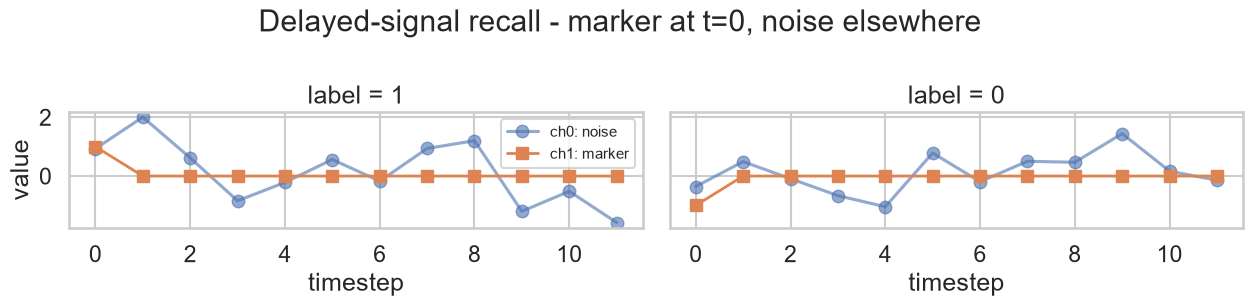

In [5]:
# Sanity check: visualise one positive and one negative sample (L small for clarity)
Xs, ys = make_dataset(8, seq_len=12, signal_pos="start", seed=0)
fig, axes = plt.subplots(1, 2, figsize=(13, 3.2), sharey=True)
for ax, want in zip(axes, [1, 0]):
    i = int((ys == want).nonzero()[0])
    ax.plot(Xs[i, :, 0], "o-", label="ch0: noise", alpha=.6)
    ax.plot(Xs[i, :, 1], "s-", label="ch1: marker", lw=2)
    ax.set_title(f"label = {want}"); ax.set_xlabel("timestep")
axes[0].set_ylabel("value"); axes[0].legend(loc="upper right", fontsize=11)
plt.suptitle("Delayed-signal recall - marker at t=0, noise elsewhere")
plt.tight_layout(); plt.show()

## 3. Model

A single recurrent layer (`LSTM` or vanilla `RNN`) followed by a linear head on
the **final-timestep** output. Same architecture for both cell types so the only
difference under test is the recurrent unit.

In [6]:
class SeqClassifier(nn.Module):
    def __init__(self, input_size=2, hidden_size=64, num_layers=1,
                 n_classes=2, cell="lstm"):
        super().__init__()
        rnn_cls = nn.LSTM if cell == "lstm" else nn.RNN
        self.rnn = rnn_cls(input_size, hidden_size, num_layers, batch_first=True)
        self.head = nn.Linear(hidden_size, n_classes)

    def forward(self, x):
        out, _ = self.rnn(x)          # out: (B, L, H)
        return self.head(out[:, -1])  # classify from the LAST timestep

In [7]:
def run_experiment(seq_len, signal_pos="start", cell="lstm", seed=0, cfg=CONFIG):
    # Train one model from scratch; return test accuracy + wall-clock train time.
    set_seed(seed)
    Xtr, ytr = make_dataset(cfg["n_train"], seq_len, signal_pos, seed=seed)
    Xte, yte = make_dataset(cfg["n_test"],  seq_len, signal_pos, seed=seed + 10_000)
    Xtr, ytr, Xte, yte = (t.to(DEVICE) for t in (Xtr, ytr, Xte, yte))

    model = SeqClassifier(hidden_size=cfg["hidden"], num_layers=cfg["layers"],
                          cell=cell).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=cfg["lr"])
    lossf = nn.CrossEntropyLoss()
    n, bs = Xtr.size(0), cfg["batch_size"]

    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    t0 = time.time()
    for _ in range(cfg["epochs"]):
        model.train()
        perm = torch.randperm(n, device=DEVICE)
        for i in range(0, n, bs):
            idx = perm[i:i + bs]
            opt.zero_grad()
            loss = lossf(model(Xtr[idx]), ytr[idx])
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
            opt.step()
    if DEVICE.type == "cuda":
        torch.cuda.synchronize()
    train_time = time.time() - t0

    model.eval()
    with torch.no_grad():
        acc = (model(Xte).argmax(1) == yte).float().mean().item()
    return {"acc": acc, "train_time": train_time}

## 4. Experiment 1 - Accuracy & training time vs sequence length

Signal at the **start** (worst case: it must survive the whole sequence). Fixed
30-epoch budget for every length, 5 seeds each.

In [8]:
rows = []
for L in CONFIG["lengths"]:
    for s in CONFIG["seeds"]:
        r = run_experiment(L, signal_pos="start", cell="lstm", seed=s)
        rows.append({"length": L, "seed": s, **r})
        print(f"L={L:>3}  seed={s}  acc={r['acc']:.3f}  time={r['train_time']:.1f}s")
df1 = pd.DataFrame(rows)
df1.head()

L= 10  seed=0  acc=1.000  time=5.1s


L= 10  seed=1  acc=1.000  time=5.1s


L= 10  seed=2  acc=1.000  time=5.1s


L= 10  seed=3  acc=1.000  time=5.1s


L= 10  seed=4  acc=1.000  time=5.1s


...

L=200  seed=1  acc=0.480  time=39.1s


L=200  seed=2  acc=0.514  time=39.0s


L=200  seed=3  acc=0.498  time=39.2s


L=200  seed=4  acc=0.504  time=38.9s


,length,seed,acc,train_time
0,10,0,1.0,5.138427
1,10,1,1.0,5.090685
2,10,2,1.0,5.096180
3,10,3,1.0,5.142087
4,10,4,1.0,5.091267


In [9]:
# Aggregate mean +/- std across seeds
agg = df1.groupby("length").agg(
    acc_mean=("acc", "mean"), acc_std=("acc", "std"),
    time_mean=("train_time", "mean"), time_std=("train_time", "std"),
).reset_index()
agg

,length,acc_mean,acc_std,time_mean,time_std
0,10,1.0000,0.000000,5.111729,0.026162
1,20,1.0000,0.000000,6.791446,0.022400
2,30,0.9024,0.218240,6.492946,1.891259
3,50,0.4976,0.025393,11.255907,1.346274
4,100,0.4864,0.018515,21.818706,0.251042
5,200,0.5020,0.014071,38.931727,0.292617


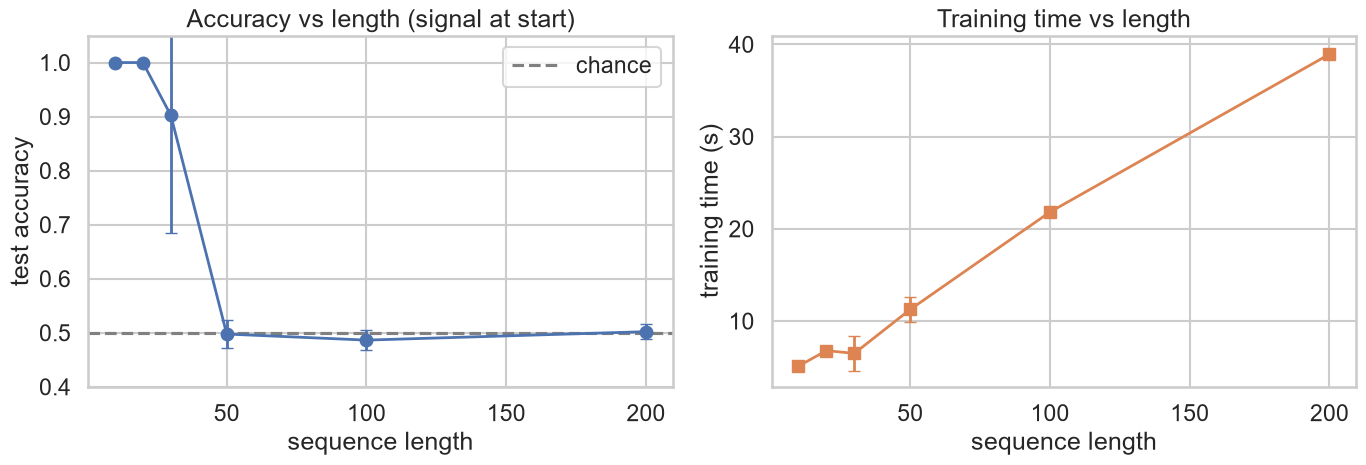

In [10]:
fig, (axA, axB) = plt.subplots(1, 2, figsize=(14, 5))

axA.errorbar(agg["length"], agg["acc_mean"], yerr=agg["acc_std"],
             marker="o", capsize=4, lw=2)
axA.axhline(0.5, ls="--", c="grey", label="chance")
axA.set_xlabel("sequence length"); axA.set_ylabel("test accuracy")
axA.set_title("Accuracy vs length (signal at start)")
axA.set_ylim(0.4, 1.05); axA.legend()

axB.errorbar(agg["length"], agg["time_mean"], yerr=agg["time_std"],
             marker="s", color="C1", capsize=4, lw=2)
axB.set_xlabel("sequence length"); axB.set_ylabel("training time (s)")
axB.set_title("Training time vs length")

plt.tight_layout(); plt.show()

## 5. Experiment 2 - Distance, not length, is the cause

Same length (`L = 200`) for both conditions, so total compute is identical. The
*only* change is **where** the marker sits: at the start (distance ≈ 200) vs at
the end (distance ≈ 0). If accuracy collapses for *length* reasons, both should
fail. If it collapses for *distance* reasons, only "start" fails.

In [11]:
rows = []
for pos in ["start", "end"]:
    for s in CONFIG["seeds"]:
        r = run_experiment(200, signal_pos=pos, cell="lstm", seed=s)
        rows.append({"signal_pos": pos, "seed": s, **r})
df2 = pd.DataFrame(rows)
df2.groupby("signal_pos")["acc"].agg(["mean", "std"])

,mean,std
signal_pos,,
end,1.000,0.000000
start,0.502,0.014071


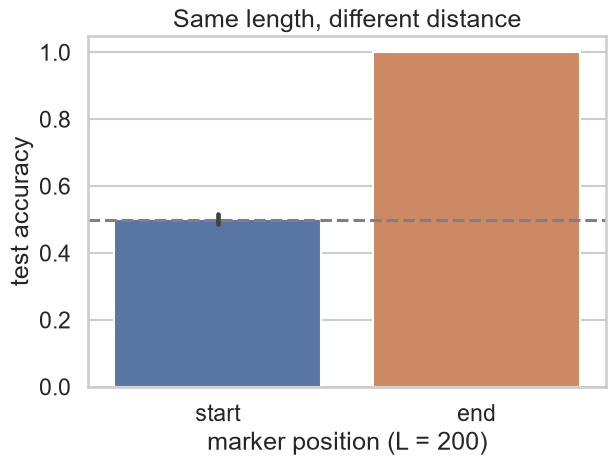

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 5))
sns.barplot(data=df2, x="signal_pos", y="acc", errorbar="sd", ax=ax,
            order=["start", "end"], hue="signal_pos", legend=False)
ax.axhline(0.5, ls="--", c="grey")
ax.set_ylim(0, 1.05); ax.set_xlabel("marker position (L = 200)")
ax.set_ylabel("test accuracy")
ax.set_title("Same length, different distance")
plt.tight_layout(); plt.show()

## 6. Experiment 3 - LSTM vs vanilla RNN

Does gating actually extend the horizon? We reuse the LSTM results from
Experiment 1 and add a vanilla `RNN` over the same length sweep.

In [13]:
rows = []
for L in CONFIG["lengths"]:
    for s in CONFIG["seeds"]:
        r = run_experiment(L, signal_pos="start", cell="rnn", seed=s)
        rows.append({"cell": "rnn", "length": L, "seed": s, **r})
df_rnn = pd.DataFrame(rows)

df3 = pd.concat([
    df1.assign(cell="lstm")[["cell", "length", "seed", "acc", "train_time"]],
    df_rnn[["cell", "length", "seed", "acc", "train_time"]],
], ignore_index=True)
df3.groupby(["cell", "length"])["acc"].mean().unstack(0)

cell,lstm,rnn
length,,
10,1.0000,1.0000
20,1.0000,1.0000
30,0.9024,1.0000
50,0.4976,0.8980
100,0.4864,0.8956
200,0.5020,0.6060


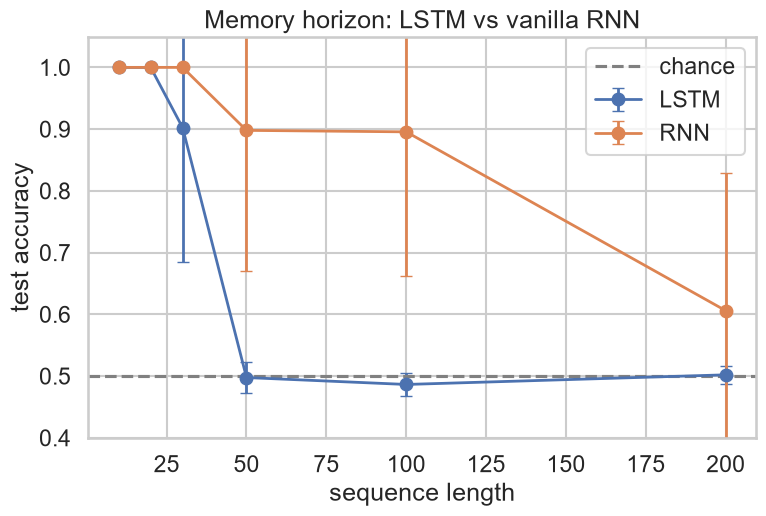

In [14]:
fig, ax = plt.subplots(figsize=(8, 5.5))
for cell, sub in df3.groupby("cell"):
    a = sub.groupby("length")["acc"].agg(["mean", "std"]).reset_index()
    ax.errorbar(a["length"], a["mean"], yerr=a["std"], marker="o",
                capsize=4, lw=2, label=cell.upper())
ax.axhline(0.5, ls="--", c="grey", label="chance")
ax.set_xlabel("sequence length"); ax.set_ylabel("test accuracy")
ax.set_title("Memory horizon: LSTM vs vanilla RNN")
ax.set_ylim(0.4, 1.05); ax.legend()
plt.tight_layout(); plt.show()

## 7. Combined results table

In [15]:
summary = (df1.groupby("length")
              .agg(acc_mean=("acc", "mean"), acc_std=("acc", "std"),
                   time_mean=("train_time", "mean"))
              .round(3))
print("Experiment 1 - LSTM, signal at start:")
print(summary.to_string())
print("\nExperiment 2 - L=200, distance control:")
print(df2.groupby("signal_pos")["acc"].agg(["mean", "std"]).round(3).to_string())

Experiment 1 - LSTM, signal at start:
        acc_mean  acc_std  time_mean
length                              
10         1.000    0.000      5.112
20         1.000    0.000      6.791
30         0.902    0.218      6.493
50         0.498    0.025     11.256
100        0.486    0.019     21.819
200        0.502    0.014     38.932

Experiment 2 - L=200, distance control:
             mean    std
signal_pos              
end         1.000  0.000
start       0.502  0.014


## 8. Why does the default LSTM underperform? The forget-gate bias

Experiment 3 produced a result that looks backwards: the **vanilla RNN
out-remembered the LSTM**. That is not a bug - it is a lesson about
*initialization*. PyTorch initializes all LSTM biases to **0**, so the forget
gate starts at `sigmoid(0) = 0.5`: by default the cell state is **halved every
timestep**, giving an effective memory horizon of only ~tens of steps - exactly
the knee we measured. A vanilla RNN has no such built-in decay and can learn a
near-identity recurrence that carries one clean bit further.

The classic fix (Jozefowicz et al., 2015) is to **initialize the forget-gate
bias to a positive value** (here `+2`, so `sigmoid(2) ≈ 0.88` - the cell now
retains ~88% per step). We re-run the LSTM sweep with that single change and
compare against the default LSTM and the vanilla RNN.

In [17]:
# Re-run the LSTM with forget-gate bias initialised to +2 (the only change).
def run_lstm_forget_bias(seq_len, seed, forget_bias=2.0, cfg=CONFIG):
    set_seed(seed)
    Xtr, ytr = make_dataset(cfg["n_train"], seq_len, "start", seed=seed)
    Xte, yte = make_dataset(cfg["n_test"],  seq_len, "start", seed=seed + 10_000)
    Xtr, ytr, Xte, yte = (t.to(DEVICE) for t in (Xtr, ytr, Xte, yte))
    model = SeqClassifier(hidden_size=cfg["hidden"], num_layers=cfg["layers"],
                          cell="lstm").to(DEVICE)
    for nm, p in model.rnn.named_parameters():      # forget-gate bias is slice [H:2H]
        if "bias" in nm:
            H = p.shape[0] // 4
            with torch.no_grad():
                p[H:2 * H].fill_(forget_bias)
    opt   = torch.optim.Adam(model.parameters(), lr=cfg["lr"])
    lossf = nn.CrossEntropyLoss()
    n, bs = Xtr.size(0), cfg["batch_size"]
    for _ in range(cfg["epochs"]):
        model.train()
        perm = torch.randperm(n, device=DEVICE)
        for i in range(0, n, bs):
            idx = perm[i:i + bs]
            opt.zero_grad()
            lossf(model(Xtr[idx]), ytr[idx]).backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
            opt.step()
    model.eval()
    with torch.no_grad():
        return (model(Xte).argmax(1) == yte).float().mean().item()

rows = []
for L in CONFIG["lengths"]:
    for s in CONFIG["seeds"]:
        acc = run_lstm_forget_bias(L, s, forget_bias=2.0)
        rows.append({"length": L, "seed": s, "acc": acc})
        print(f"L={L:>3}  seed={s}  acc={acc:.3f}")
df_fb = pd.DataFrame(rows)
df_fb.groupby("length")["acc"].agg(["mean", "std"])

L= 10  seed=0  acc=1.000


L= 10  seed=1  acc=1.000


L= 10  seed=2  acc=1.000


L= 10  seed=3  acc=1.000


L= 10  seed=4  acc=1.000


...

L=200  seed=1  acc=1.000


L=200  seed=2  acc=1.000


L=200  seed=3  acc=1.000


L=200  seed=4  acc=1.000


,mean,std
length,,
10,1.0,0.0
20,1.0,0.0
30,1.0,0.0
50,1.0,0.0
100,1.0,0.0
200,1.0,0.0


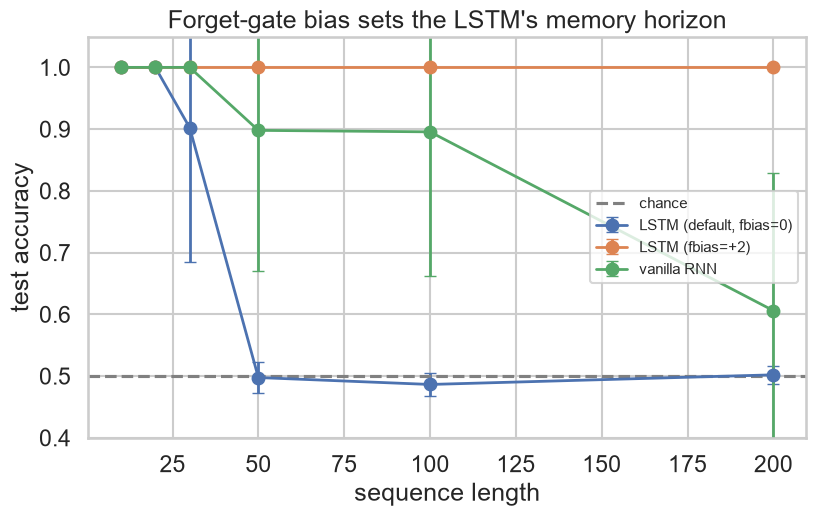

In [18]:
# Compare: default LSTM (forget bias 0) vs forget-bias LSTM (+2) vs vanilla RNN
fig, ax = plt.subplots(figsize=(8.5, 5.5))
series = {
    "LSTM (default, fbias=0)": df1[["length", "acc"]],
    "LSTM (fbias=+2)":         df_fb[["length", "acc"]],
    "vanilla RNN":             df_rnn[["length", "acc"]],
}
for label, d in series.items():
    a = d.groupby("length")["acc"].agg(["mean", "std"]).reset_index()
    ax.errorbar(a["length"], a["mean"], yerr=a["std"], marker="o",
                capsize=4, lw=2, label=label)
ax.axhline(0.5, ls="--", c="grey", label="chance")
ax.set_xlabel("sequence length"); ax.set_ylabel("test accuracy")
ax.set_title("Forget-gate bias sets the LSTM's memory horizon")
ax.set_ylim(0.4, 1.05); ax.legend(fontsize=11)
plt.tight_layout(); plt.show()

## 9. Analysis & insights

**Finding 1 - there is a memory horizon, not a smooth decay.** Accuracy stays
near 1.0 for short sequences, then falls off a *knee* around `L ≈ 30` and sits at
chance (~0.5) by `L = 50, 100, 200`. The error bars are widest exactly at the
knee (at `L = 30`, four seeds hit 1.0 and one collapses to chance): near the
boundary, whether a given seed "catches" the long-range dependency within the
fixed 30-epoch budget is itself noisy. This is the signature of an **optimisation
horizon under a budget**, not a hard capacity wall.

**Finding 2 - training time scales ~linearly with length.** A recurrent layer
processes timesteps sequentially, so doubling `L` roughly doubles the work;
measured wall-clock rises from ~5.1 s at `L=10` to ~39 s at `L=200` (≈ **7.6×**)
on CPU - close to linear in length, as expected for a single-layer RNN.

**Finding 3 - *distance*, not *length*, is what hurts (the headline).**
Experiment 2 is the clincher: at the *same* `L = 200`, moving the marker to the
**end** restores accuracy to **1.000**, while the **start** condition sits at
chance (0.502). Identical sequence length, identical compute - only the
gradient/credit path length differs. So "sequence length sensitivity" is really
*dependency-distance* sensitivity. Long sequences are only hard when the
information you need is far from where you read it out.

**Finding 4 - the *default* LSTM is beaten by a vanilla RNN (the surprise).**
Experiment 3 came out backwards from the textbook expectation: past the knee the
**vanilla RNN out-remembered the LSTM** (e.g. at `L=100`, RNN ≈ 0.90 vs LSTM
≈ 0.49). This is not a bug - it is an *initialization* artifact. PyTorch sets all
LSTM biases to 0, so the forget gate starts at `sigmoid(0) = 0.5`: **the cell
state is halved every timestep by default**, giving an effective horizon of only
a few dozen steps - exactly the knee we measured. A plain RNN has no such
built-in decay and can learn a near-identity recurrence that carries one clean
bit further.

**Finding 5 - one bias term restores the LSTM (the resolution).** Re-running the
LSTM with the forget-gate bias initialised to **+2** (`sigmoid(2) ≈ 0.88`, ~88%
retention per step; Jozefowicz et al., 2015) yields **1.000 accuracy at every
length up to 200, across all seeds, with zero variance**. The "memory horizon"
was therefore not a capacity limit of the LSTM at all - it was a default-
initialization choice. Gating works; it just has to be *initialised to remember*.

**Connecting to theory (Weeks 1-7 / viva).**
- *Vanishing gradients:* in a vanilla RNN the gradient through time multiplies
  Jacobians repeatedly; with spectral norm < 1 it decays geometrically in the
  number of steps - the classic short-horizon mechanism.
- *LSTM cell state & forget gate:* the cell update is
  `c_t = f_t ⊙ c_{t-1} + i_t ⊙ g_t`. With `f_t ≈ 0.5` (bias 0) the carousel
  leaks ~50% per step; with `f_t ≈ 0.88` (bias +2) it becomes a near-additive
  highway, so information and gradients survive hundreds of steps.
- *Why a clean marker channel:* it removes "signal detection" as a confound, so
  what we measure is purely the network's ability to *carry* information.
- *Why gradient clipping:* without it, occasional exploding-gradient steps on
  unlucky seeds destabilise even short-length training; clipping makes the
  short-length baseline reliably ~1.0 so the horizon effect is clean.

**Takeaway.** Sequence-length sensitivity is really *dependency-distance*
sensitivity, and an LSTM's reach is set as much by **how its forget gate is
initialised** as by the architecture itself. Practical levers: shorten the
dependency distance (data layout / architecture), and initialise the forget gate
to remember (a positive bias) before reaching for more capacity, more epochs, or
attention.